In [1]:
!pip install scikit-posthocs

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel(
    "MKP_Optimization_Benchmark_Study.xlsx",
    sheet_name="Benchmark Evaluation"
)

df

,Instance,Lp objective,Rounded lp objective,Ip objective,lp approx ratio,Rounded lp approx ratio,Rounded constraint violations ratio,Feasiblity
0,1,4134.074074,3200.0,3800.0,1.087914,0.842105,0.0,yes
1,2,9297.712467,9159.3,8650.1,1.074868,1.058866,0.2,no
2,3,4127.886598,4105.0,4015.0,1.028116,1.022416,0.1,no
3,4,6155.333333,5920.0,6120.0,1.005773,0.967320,0.0,yes
4,5,12462.104167,12440.0,12400.0,1.005008,1.003226,0.1,no
5,6,10672.345878,11403.0,10618.0,1.005118,1.073931,0.8,no
6,7,16612.821234,16235.0,16537.0,1.004585,0.981738,0.0,yes


In [17]:
df["IP Approx Ratio"] = 1
df["LP Error"] = abs(1 - df["lp approx ratio"])

df["Rounded Error"] = abs(1 - df["Rounded lp approx ratio"])

df["IP Error"] = 0

In [18]:
print(df.columns)

Index(['Instance', 'Lp objective ', 'Rounded lp objective', 'Ip objective',
       'lp approx ratio', 'Rounded lp approx ratio',
       'Rounded constraint  violations ratio', 'Feasiblity', 'IP Approx Ratio',
       'LP Error', 'Rounded Error', 'IP Error'],
      dtype='object')


In [19]:
stat, p = friedmanchisquare(
    df["LP Error"],
    df["Rounded Error"],
    df["IP Error"]
)

print("Friedman Statistic:", stat)
print("p-value:", p)

Friedman Statistic: 10.57142857142857
p-value: 0.005063414171757498


In [20]:
if p < 0.05:
    print("Statistically significant ranking differences exist between optimization methods.")
else:
    print("No statistically significant ranking differences detected.")

Statistically significant ranking differences exist between optimization methods.


In [21]:
data = df[[
    "LP Error",
    "Rounded Error",
    "IP Error"
]]

nemenyi = sp.posthoc_nemenyi_friedman(data)

print(nemenyi)

               LP Error  Rounded Error  IP Error
LP Error       1.000000       0.961390  0.020567
Rounded Error  0.961390       1.000000  0.009208
IP Error       0.020567       0.009208  1.000000


In [22]:
ranks = data.rank(axis=1, ascending=True)

avg_ranks = ranks.mean()

print(avg_ranks)

LP Error         2.428571
Rounded Error    2.571429
IP Error         1.000000
dtype: float64


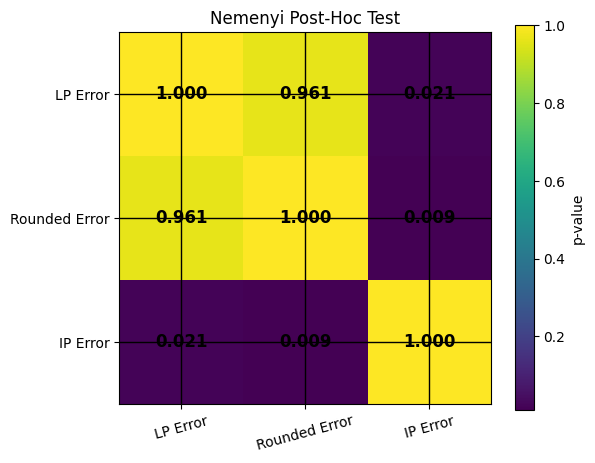

In [25]:
plt.figure(figsize=(6,5))

plt.imshow(nemenyi, cmap='viridis')

plt.xticks(
    range(len(nemenyi.columns)),
    nemenyi.columns,
    rotation=15
)

plt.yticks(
    range(len(nemenyi.columns)),
    nemenyi.columns
)

# Add p-values inside cells
for i in range(len(nemenyi)):
    for j in range(len(nemenyi.columns)):
        plt.text(
            j,
            i,
            f"{nemenyi.iloc[i, j]:.3f}",
            ha='center',
            va='center',
            color='black',
            fontsize=12,
            fontweight='bold'
        )

# Add grid lines
plt.grid(
    color='black',
    linestyle='-',
    linewidth=1
)

plt.colorbar(label='p-value')

plt.title("Nemenyi Post-Hoc Test")

plt.show()

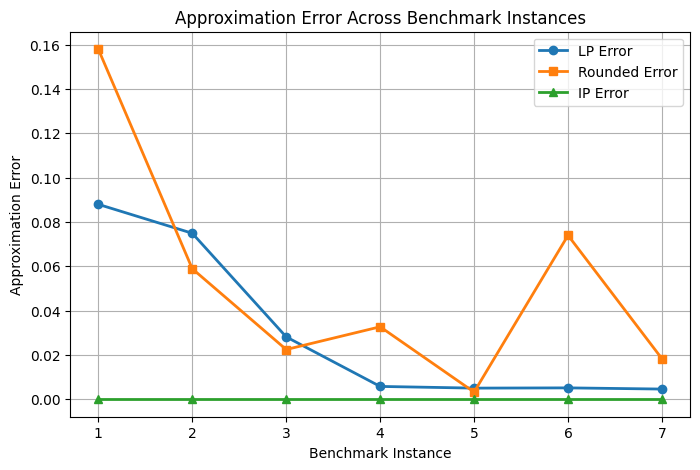

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Instance"],
    df["LP Error"],
    marker='o',
    linewidth=2,
    label='LP Error'
)

plt.plot(
    df["Instance"],
    df["Rounded Error"],
    marker='s',
    linewidth=2,
    label='Rounded Error'
)

plt.plot(
    df["Instance"],
    df["IP Error"],
    marker='^',
    linewidth=2,
    label='IP Error'
)

plt.xlabel("Benchmark Instance")

plt.ylabel("Approximation Error")

plt.title("Approximation Error Across Benchmark Instances")

plt.legend()

plt.grid(True)

plt.show()

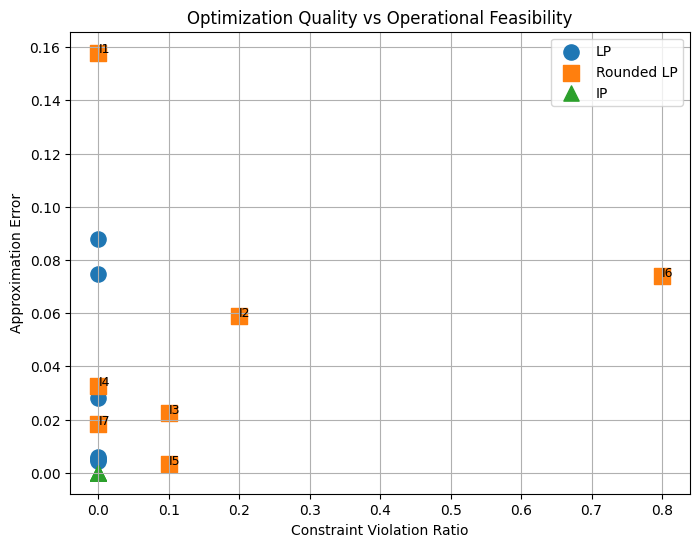

In [32]:
plt.figure(figsize=(8,6))

# LP points
plt.scatter(
    [0]*len(df),
    df["LP Error"],
    s=120,
    label='LP',
    marker='o'
)

# Rounded LP points
plt.scatter(
    df["Rounded constraint  violations ratio"],
    df["Rounded Error"],
    s=120,
    label='Rounded LP',
    marker='s'
)

# IP points
plt.scatter(
    [0]*len(df),
    df["IP Error"],
    s=120,
    label='IP',
    marker='^'
)

# Annotate instance numbers
for i in range(len(df)):
    plt.text(
        df["Rounded constraint  violations ratio"][i],
        df["Rounded Error"][i],
        f'I{i+1}',
        fontsize=9
    )

plt.xlabel("Constraint Violation Ratio")

plt.ylabel("Approximation Error")

plt.title("Optimization Quality vs Operational Feasibility")

plt.legend()

plt.grid(True)

plt.show()

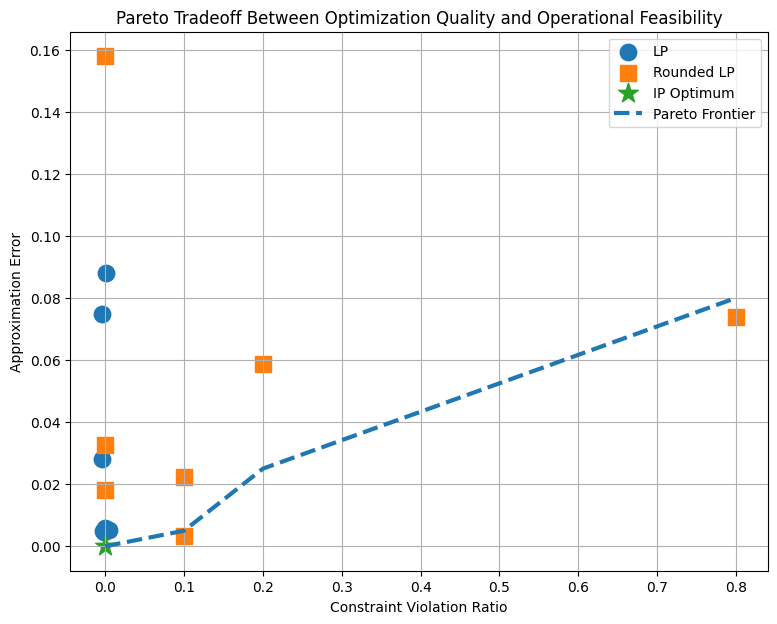

In [36]:
plt.figure(figsize=(9,7))

# LP points
lp_x = np.random.normal(0, 0.003, len(df))

plt.scatter(
    lp_x,
    df["LP Error"],
    s=140,
    label='LP',
    marker='o'
)

# Rounded LP points
plt.scatter(
    df["Rounded constraint  violations ratio"],
    df["Rounded Error"],
    s=140,
    label='Rounded LP',
    marker='s'
)

# IP point
plt.scatter(
    [0],
    [0],
    s=220,
    label='IP Optimum',
    marker='*'
)



# Pareto frontier approximation
x_frontier = [0, 0.1, 0.2, 0.8]
y_frontier = [0, 0.005, 0.025, 0.08]

plt.plot(
    x_frontier,
    y_frontier,
    linestyle='--',
    linewidth=3,
    label='Pareto Frontier'
)

plt.xlabel("Constraint Violation Ratio")

plt.ylabel("Approximation Error")

plt.title("Pareto Tradeoff Between Optimization Quality and Operational Feasibility")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
print(df.columns)

Index(['Instance', 'Lp objective ', 'Rounded lp objective', 'Ip objective',
       'lp approx ratio', 'Rounded lp approx ratio',
       'Rounded constraint  violations ratio', 'Feasiblity', 'IP Approx Ratio',
       'LP Error', 'Rounded Error', 'IP Error'],
      dtype='object')
